In assessing model performance, we will compare the agreement between predicted and actual values. Let's call this the "primary comparison": pairwise distances between predicted and actual values for a given cell type in a given stimulation condition.  

However, since the prediction is generative and we don't have 1-to-1 comparisons with actual values, we need baseline comparisons that we expect the predicted and actual comparisons to be better than. These baselines would be:

1. The distance between cells of different contexts (same cell type, different stimulation conditions). We would expect this distance to be higher than our "primary comparison".
2. A null distribution of distances of a random subset of cells of the same size. 

We would expect the distances of both these baselines to be larger than the primary comparison ("primary expectation").

Let's define the "experimental comparison" as the pairwise distances within actual values for a given cell type in a stimulation condition. For the primary expectation to hold true, we need to ensure that the distances of the two baselines are larger than the experimental comparison first. Otherwise, even if the prediction is perfect and one-to-one, the primary expectation won't hold true.  

In [3]:
import os
import itertools
from tqdm import tqdm

import numpy as np
import pandas as pd
import scanpy as sc

import scipy
from statsmodels.stats.multitest import multipletests
from cliffs_delta import cliffs_delta

from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import calculate_pairwise_distances, get_upper_triangle, cohen_d, quantify_cluster_distance


In [20]:
# n_cores = 20
# os.environ["OMP_NUM_THREADS"] = str(n_cores)
# os.environ["MKL_NUM_THREADS"] = str(n_cores)
# os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
# os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
# os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
md = tf_adata.obs.copy()

## Baseline 1:

In [6]:
cell_types = md.seurat_annotations.unique()
stimulation_conditions = md.stim.unique()

dist_dict = {}
pvals = pd.DataFrame(index = cell_types, columns = stimulation_conditions.tolist())
effect_sizes = pvals.copy()

In [8]:
for ct in tqdm(cell_types):
    md_ = md[md.seurat_annotations == ct]

    # filter to cell of interest
    ctrl_cells = md_[md_.stim == stimulation_conditions[0]].index.tolist()
    stim_cells = md_[md_.stim == stimulation_conditions[1]].index.tolist()

    ctrl_X = tf_adata[ctrl_cells, :].to_df()
    stim_X = tf_adata[stim_cells, :].to_df()

    # get distances
    cross_dist = calculate_pairwise_distances(df1 = ctrl_X,
                                            df2 = stim_X,
                                            distance_metric = 'euclidean',
                                            axis = 0, # compare the cells
                                           ).values.flatten()

    ctrl_dist = get_upper_triangle(calculate_pairwise_distances(df1 = ctrl_X,
                                                        df2 = None,
                                                        distance_metric = 'euclidean',
                                                        axis = 0, # compare the cells
                                                       ))
    stim_dist = get_upper_triangle(calculate_pairwise_distances(df1 = stim_X,
                                                        df2 = None,
                                                        distance_metric = 'euclidean',
                                                        axis = 0, # compare the cells
                                                       ))

    # get the statistics (Welch's t-test and cohen's d -- distances are Gaussian)
    _, p_val_ctrl = scipy.stats.ttest_ind(ctrl_dist, cross_dist, alternative = 'less', equal_var=False)
    _, p_val_stim = scipy.stats.ttest_ind(stim_dist, cross_dist, alternative = 'less', equal_var=False)

    cd_ctrl = cohen_d(ctrl_dist, cross_dist)
    cd_stim = cohen_d(stim_dist, cross_dist)

    # store
    dist_dict[ct] = {'cross': cross_dist, 'ctrl': ctrl_dist, 'stim': stim_dist}

    pvals.loc[ct, 'CTRL'] = p_val_ctrl
    pvals.loc[ct, 'STIM'] = p_val_stim

    effect_sizes.loc[ct, 'CTRL'] = cd_ctrl
    effect_sizes.loc[ct, 'STIM'] = cd_stim

# apply multiple test correction
_, fdr, _, _ = multipletests(pvals.values.flatten(), method='fdr_bh')
fdrs = pd.DataFrame(fdr.reshape(pvals.shape), columns=pvals.columns, index = pvals.index)

# basic formatting
fdrs.columns = fdrs.columns.str.lower()
effect_sizes.columns = effect_sizes.columns.str.lower()

100%|█████████████████████████████████████████████| 13/13 [00:09<00:00,  1.44it/s]


Visualize the results:

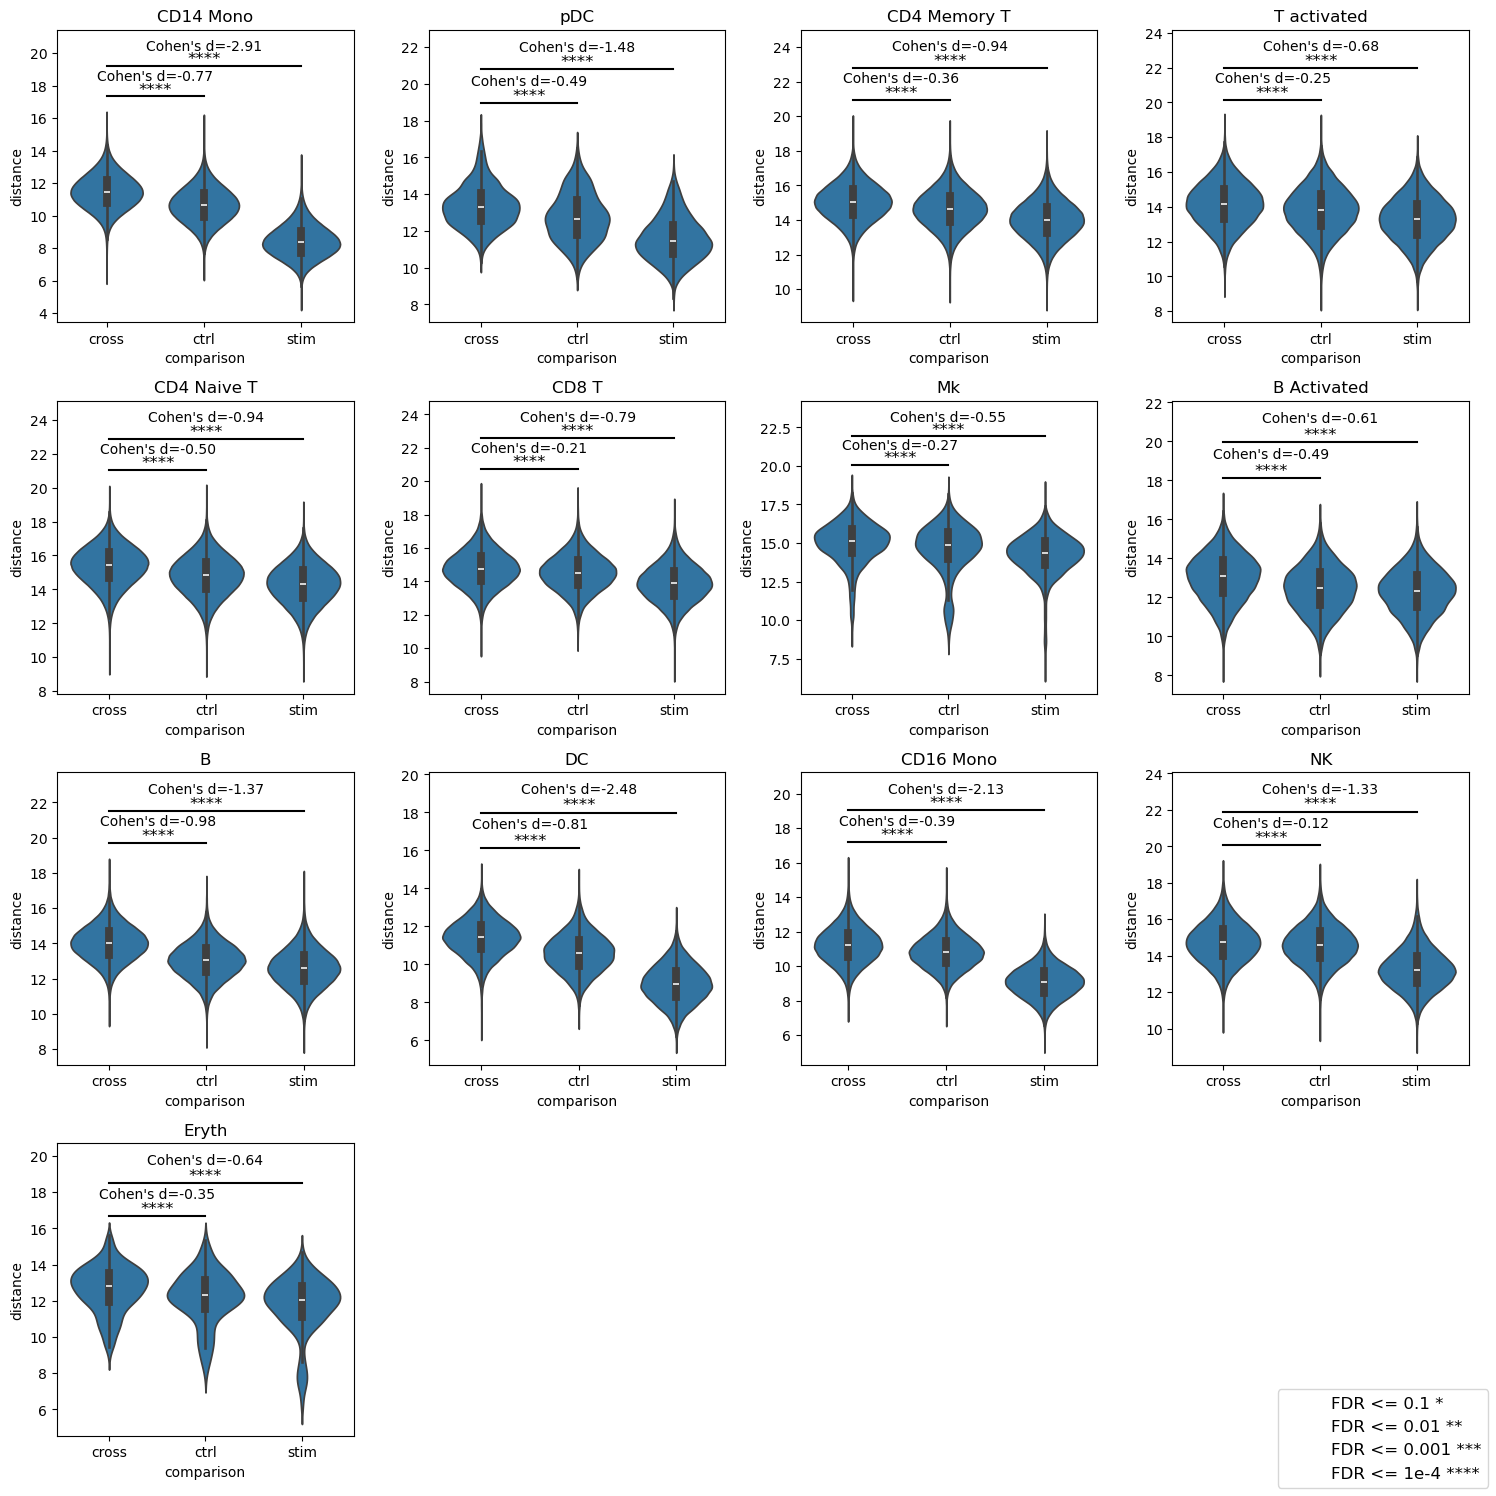

In [9]:
n_cell_types = cell_types.shape[0]
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

# format data
plot_data = []
for cell_type, dists in dist_dict.items():
    for key in ['cross', 'ctrl', 'stim']:
        # Each element in the dict is assumed to be an array or list of values
        values = dists[key]  # Should be a numpy array or list
        if isinstance(values, np.ndarray) or isinstance(values, list):
            for val in values:
                plot_data.append({'cell_type': cell_type, 'comparison': key, 'distance': val})
plot_df = pd.DataFrame(plot_data)

# Step 3: Iterate through cell types and create violin plots with annotations
for i, cell_type in enumerate(cell_types):
    ax = axes[i]
    
    # Filter data for the current cell type
    data = plot_df[plot_df['cell_type'] == cell_type]
    
    # Create the violin plot
    sns.violinplot(x='comparison', y='distance', data=data, ax=ax)
    ax.set_title(cell_type)
    
    # Step 4: Annotate significance and effect size
    fdr = fdrs.loc[cell_type]
    effect_size = effect_sizes.loc[cell_type]
    
    y_max = data['distance'].max()

    comparisons = [('cross', 'ctrl'), ('cross', 'stim')]
    x_pos = {'cross': 0, 'ctrl': 1, 'stim': 2}

    start_vals = [1.05, 2.9]
    comparison_heights = [y_max + start_vals[0], y_max + start_vals[1]]  # Stagger the bars
    annotation_heights = [y_max + start_vals[0] + 0.15, y_max + start_vals[1] + 0.15]  # Stagger significance
    effect_size_heights = [y_max + start_vals[0] + 1, y_max + start_vals[1] + 1]  # Stagger effect sizes

    for j, ((comp1, comp2), p_value, effect) in enumerate(zip(comparisons, fdr, effect_size)):
        x_mid = (x_pos[comp1] + x_pos[comp2]) / 2

        significance = ""
        if p_value <= 1e-4:
            significance = "****"
        elif p_value <= 0.001:
            significance = "***"
        elif p_value <= 0.01:
            significance = "**"
        elif p_value <= 0.1:
            significance = "*"

        ax.plot([x_pos[comp1], x_pos[comp2]], [comparison_heights[j], comparison_heights[j]], color='black', lw=1.5)

        if significance:
            ax.text(x_mid, annotation_heights[j], significance, ha='center', color='black', fontsize=12)
        ax.text(x_mid, effect_size_heights[j], f"Cohen's d={effect:.2f}", ha='center', color='black', fontsize=10)
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + 1.5)
# Step 5: Add a significance legend
handles = [plt.Line2D([0], [0], color='black', marker='', linestyle='None', label='FDR <= 0.1 *'),
           plt.Line2D([0], [0], color='black', marker='', linestyle='None', label='FDR <= 0.01 **'),
           plt.Line2D([0], [0], color='black', marker='', linestyle='None', label='FDR <= 0.001 ***'),
           plt.Line2D([0], [0], color='black', marker='', linestyle='None', label='FDR <= 1e-4 ****')]

fig.legend(handles=handles, loc='lower right', fontsize=12)
fig.tight_layout()

for i in range(13, 16):
    fig.delaxes(axes[i])

plt.show()

All are significant as expected, but effect sizes tend to be small to medium. Smaller effect sizes are assumed to be harder tasks for the model.

## Baseline 2

In [74]:
tf_adata.obs['condition'] = md.stim.astype(str) + '^' + md.seurat_annotations.astype(str)

label_combinations = list(itertools.combinations_with_replacement(sorted(set(tf_adata.obs['condition'])), 2))
comparison_combination_subset = [comb for comb in label_combinations if comb[0] == comb[1]]


In [30]:
distance_metric = 'euclidean'
# distances_df = quantify_cluster_distance(tf_adata = tf_adata, 
#                                          label = 'condition', 
#                                          comparison_combination_subset = comparison_combination_subset,
#                                          comparison_subset = None, 
#                                          label_subset = None,
#                                          include_self = True,
#                                          distance_metric = distance_metric, 
#                                          normal = True, 
#                                          use_pcs = False, 
#                                          rank = None, 
#                                          n_perm = 1000, 
#                                          alternative = 'less', 
#                                          seed = 888,
#                                          n_cores = min(len(comparison_combination_subset), n_cores))
# distances_df.to_csv(os.path.join(data_path, 'processed', 'kang_experimental_self' + distance_metric + '_distances.csv'))

distances_df = pd.read_csv(os.path.join(data_path, 'processed', 'kang_experimental_self' + distance_metric + '_distances.csv'), 
            index_col = 0)
distances_df.index = pd.Series(distances_df.index).apply(lambda x: x.split('-')[0]).tolist()

/tmp/ipykernel_1333303/2183029180.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


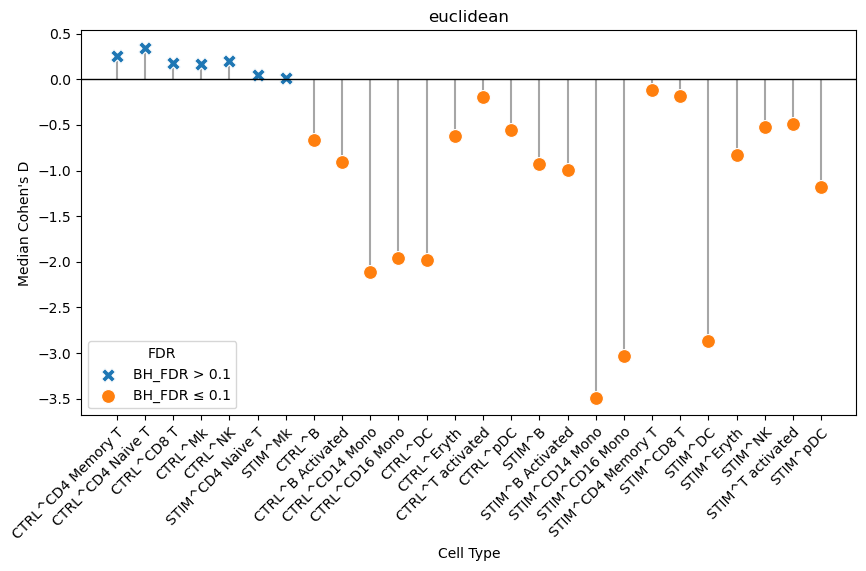

In [27]:
fig, ax = plt.subplots(figsize = (10,5))

distances_df['marker'] = distances_df['BH_FDR'].apply(lambda x: 'o' if x <= 0.1 else 'X')
distances_df['FDR Label'] = distances_df['BH_FDR'].apply(lambda x: 'BH_FDR ≤ 0.1' if x <= 0.1 else 'BH_FDR > 0.1')


# Plot the heads (markers) and create a legend
for label, group in distances_df.groupby('FDR Label'):
    sns.scatterplot(
        x=group.index,
        y=group['median_cd'],
        marker=group['marker'].iloc[0],
        s=100,
        label=label, ax = ax,
    )
ax.vlines(x=distances_df.index, ymin=0, ymax=distances_df['median_cd'], color='gray', alpha=0.7, zorder=0)
ax.axhline(0, color='black', linewidth=1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.set_xlabel('Cell Type')
ax.set_ylabel("Median Cohen's D")
ax.set_title(distance_metric)
ax.legend(title='FDR')

Our expectation for baseline #2 holds true for most cases. However, there is a small minority for which this does not hold true. For these, let's see whether we can achieve our expectation on a subset of the TFs -- those that are differentially expressed. We will do that specific condition vs the rest of cells (since the background is just random, so not doing STIM vs CTRL).

Let's start by getting the DE genes (MWU FDR <= 0.1, abs Cliff's Delta > 0.33):

In [19]:
distance_metric = 'euclidean'
distances_df = pd.read_csv(os.path.join(data_path, 'processed', 'kang_experimental_self' + distance_metric + '_distances.csv'), 
            index_col = 0)
# distances_df.index = pd.Series(distances_df.index).apply(lambda x: x.split('-')[0]).tolist()

In [8]:
non_significant = distances_df[distances_df.BH_FDR > 0.1]
de_tfs = {}

for ns in tqdm(non_significant.index):
    ns = tuple(ns.split('-'))
    cond, ct = ns[0].split('^')
    c1 = tf_adata[tf_adata.obs[(tf_adata.obs.stim == cond) & (tf_adata.obs.seurat_annotations == ct)].index.tolist(),].to_df()
    c2 = tf_adata[tf_adata.obs[~((tf_adata.obs.stim == cond) & (tf_adata.obs.seurat_annotations == ct))].index.tolist(),].to_df()

    pvals = mannwhitneyu(c1, c2, alternative = 'two-sided', axis = 0).pvalue
    _, fdrs, _, _ = multipletests(pvals, method='fdr_bh')

    cd_vals = []
    for feature in tf_adata.var_names:
        if cliffs_delta(c1[feature], c2[feature])[1] in ['medium', 'large']:
            cd_vals.append(True)
        else:
            cd_vals.append(False)
    cd_vals = np.array(cd_vals)

    de_tfs[ns] = tf_adata.var_names[np.intersect1d(np.where(fdrs <= 0.1), np.where(cd_vals))].tolist()
    


100%|███████████████████████████████████████████████| 7/7 [00:39<00:00,  5.65s/it]


Get distances for the DE TFs:

In [25]:
# tf_adata.obs['condition'] = md.stim.astype(str) + '^' + md.seurat_annotations.astype(str)

# ns_ddf = pd.DataFrame(columns = distances_df.columns)

# for comparison, de_tf in de_tfs.items():
#     distances_df = quantify_cluster_distance(tf_adata = tf_adata, 
#                                              label = 'condition', 
#                                              comparison_combination_subset = [comparison],
#                                              comparison_subset = None, 
#                                              label_subset = None,
#                                              include_self = True,
#                                              feature_subset = de_tf,
#                                              distance_metric = distance_metric, 
#                                              normal = True, 
#                                              use_pcs = False, 
#                                              rank = None, 
#                                              n_perm = 1000, 
#                                              alternative = 'less', 
#                                              seed = 888,
#                                              n_cores = 1)
#     ns_ddf = pd.concat([ns_ddf, distances_df], axis = 0, ignore_index = False)

# _, fdr, _, _ = multipletests(ns_ddf.pval, method='fdr_bh')
# ns_ddf['BH_FDR'] = fdr
# ns_ddf.to_csv(os.path.join(data_path, 'processed', 'kang_experimental_self_de' + distance_metric + '_distances.csv'))

ns_ddf = pd.read_csv(os.path.join(data_path, 'processed', 'kang_experimental_self_de' + distance_metric + '_distances.csv'), 
            index_col = 0)
ns_ddf.index = pd.Series(ns_ddf.index).apply(lambda x: x.split('-')[0]).tolist()

100%|███████████████████████████████████████████████| 1/1 [00:05<00:00,  5.92s/it]


/tmp/ipykernel_1338780/1093954002.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


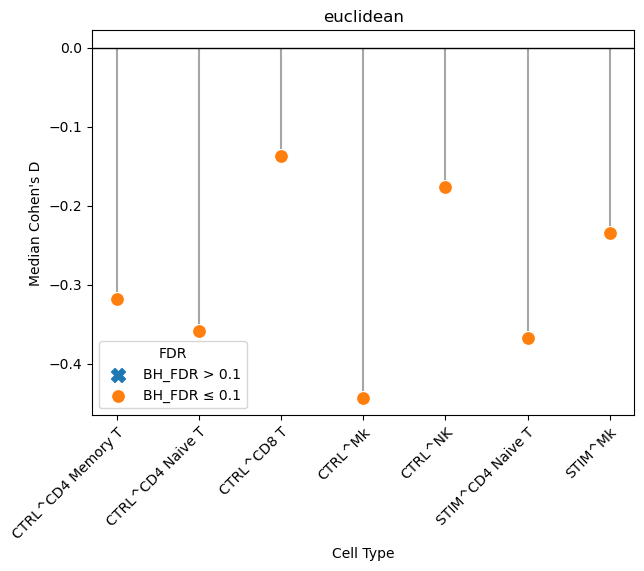

In [48]:
fig, ax = plt.subplots(figsize = (7,5))

fdr_conditions = ['BH_FDR ≤ 0.1', 'BH_FDR > 0.1']
fdr_markers = {'BH_FDR ≤ 0.1': 'o', 'BH_FDR > 0.1': 'X'}

ns_ddf['marker'] = ns_ddf['BH_FDR'].apply(lambda x: 'o' if x <= 0.1 else 'X')
ns_ddf['FDR Label'] = ns_ddf['BH_FDR'].apply(lambda x: 'BH_FDR ≤ 0.1' if x <= 0.1 else 'BH_FDR > 0.1')

for label in fdr_conditions:
    if label not in ns_ddf['FDR Label'].unique():
        ax.scatter([], [], marker=fdr_markers[label], s=100, label=label)

for label, group in ns_ddf.groupby('FDR Label'):
    sns.scatterplot(
        x=group.index,
        y=group['median_cd'],
        marker=group['marker'].iloc[0],
        s=100,
        label=label, ax = ax,
    )
    
ax.vlines(x=ns_ddf.index, ymin=0, ymax=ns_ddf['median_cd'], color='gray', alpha=0.7, zorder=0)
ax.axhline(0, color='black', linewidth=1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.set_xlabel('Cell Type')
ax.set_ylabel("Median Cohen's D")
ax.set_title(distance_metric)
ax.legend(title='FDR')

We see that for the subset of conditions that were not significantly lower distances than random, they still show separation on the DE TFs.

## Additionally
Let's see whether cross-stim distances are larger than random, which would be our expectation.

In [4]:
tf_adata.obs['condition'] = md.stim.astype(str) + '^' + md.seurat_annotations.astype(str)

label_combinations = list(itertools.combinations(sorted(set(tf_adata.obs['condition'])), 2))
comparison_combination_subset = [comb for comb in label_combinations if comb[0].split('^')[1] == comb[1].split('^')[1]]


In [12]:
# for distance_metric in ['euclidean', 'manhattan', 'pearson', 'spearman']:
# # for distance_metric in ['manhattan', 'pearson', 'spearman']:
#     distances_df = quantify_cluster_distance(tf_adata = tf_adata, 
#                                              label = 'condition', 
#                                              comparison_combination_subset = comparison_combination_subset,
#                                              comparison_subset = None, 
#                                              label_subset = None, 
#                                              include_self = False, 
#                                              distance_metric = distance_metric, 
#                                              normal = True, 
#                                              use_pcs = False, 
#                                              rank = None, 
#                                              n_perm = 1000, 
#                                              alternative = 'greater', 
#                                              seed = 888,
#                                              n_cores = len(comparison_combination_subset))
#     distances_df.to_csv(os.path.join(data_path, 'processed', 'kang_experimental_' + distance_metric + '_distances.csv'))

distances_df_dict = {}
for distance_metric in ['euclidean', 'manhattan', 'pearson', 'spearman']:
    distances_df = pd.read_csv(os.path.join(data_path, 'processed', 'kang_experimental_' + distance_metric + '_distances.csv'), index_col = 0)
    distances_df.index = pd.Series(distances_df.index).apply(lambda x: x.split('^')[-1]).tolist()
    distances_df_dict[distance_metric] = distances_df

/tmp/ipykernel_1331811/3660772718.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
/tmp/ipykernel_1331811/3660772718.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
/tmp/ipykernel_1331811/3660772718.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
/tmp/ipykernel_1331811/3660772718.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotat

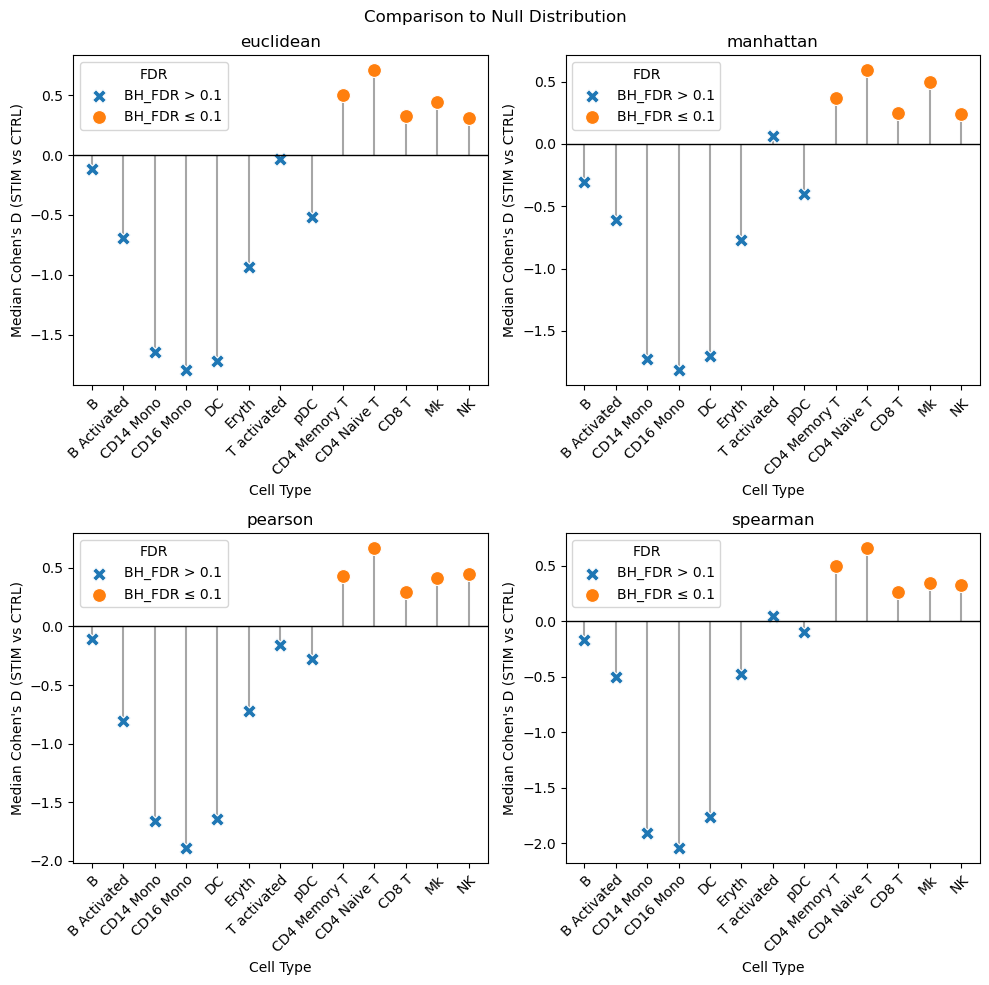

In [13]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10, 10))

axes = axes.flatten()

for i, (distance_metric, distances_df) in enumerate(distances_df_dict.items()):
    ax = axes[i]
    distances_df['marker'] = distances_df['BH_FDR'].apply(lambda x: 'o' if x <= 0.1 else 'X')
    distances_df['FDR Label'] = distances_df['BH_FDR'].apply(lambda x: 'BH_FDR ≤ 0.1' if x <= 0.1 else 'BH_FDR > 0.1')


    # Plot the heads (markers) and create a legend
    for label, group in distances_df.groupby('FDR Label'):
        sns.scatterplot(
            x=group.index,
            y=group['median_cd'],
            marker=group['marker'].iloc[0],
            s=100,
            label=label, ax = ax,
        )
    ax.vlines(x=distances_df.index, ymin=0, ymax=distances_df['median_cd'], color='gray', alpha=0.7, zorder=0)
    ax.axhline(0, color='black', linewidth=1)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_xlabel('Cell Type')
    ax.set_ylabel("Median Cohen's D (STIM vs CTRL)")
    ax.set_title(distance_metric)
    ax.legend(title='FDR')

fig.suptitle('Comparison to Null Distribution')
fig.tight_layout()
plt.show()
